In [5]:
%matplotlib inline

In [4]:
%pip install --upgrade --force-reinstall "protobuf==4.25.9"

  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires jax, which is not installed.
mediapipe 0.10.21 requires jaxlib, which is not installed.
tensorflow-metadata 1.14.0 requires protobuf<4.21,>=3.20.3, but you have protobuf 4.25.9 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install mediapipe-model-maker


In [1]:
import os
import tensorflow as tf
assert tf.__version__.startswith('2')

from mediapipe_model_maker import gesture_recognizer

import matplotlib.pyplot as plt


2026-07-09 01:25:15.612433: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-09 01:25:15.613991: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-09 01:25:15.635902: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-09 01:25:15.635940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-09 01:25:15.636752: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
BASE_PATH = os.path.join(os.getcwd(), 'dataset/images')
print(BASE_PATH)
DATASET_PATHS = {
  "train" : os.path.join(BASE_PATH, "train"),
  "test" : os.path.join(BASE_PATH, "test"),
  "val" : os.path.join(BASE_PATH, "val")
}

labels = []
for i in os.listdir(DATASET_PATHS["train"]):
  if os.path.isdir(os.path.join(DATASET_PATHS["train"], i)):
    labels.append(i)
print(labels)

/home/segev/mediapipe-training/dataset/images
['grip', 'dislike', 'like', 'fist', 'stop', 'call', 'none', 'peace', 'ok', 'four', 'one', 'three2']


/tmp/ipykernel_33769/702240781.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, NUM_EXAMPLES, figsize=(10,2))


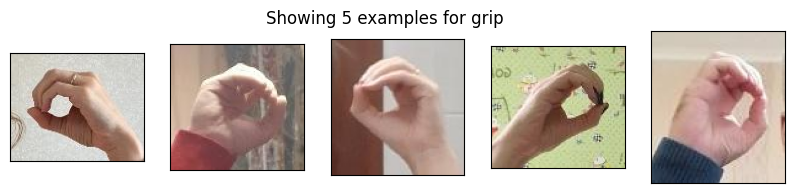

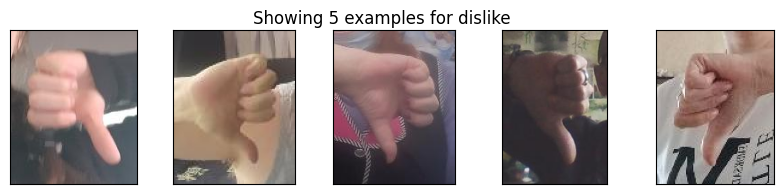

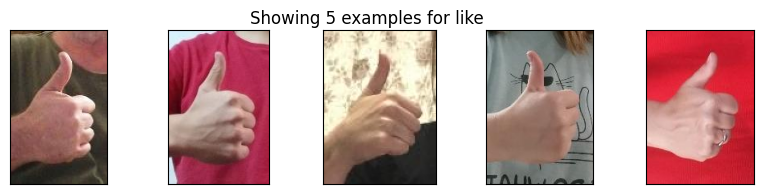

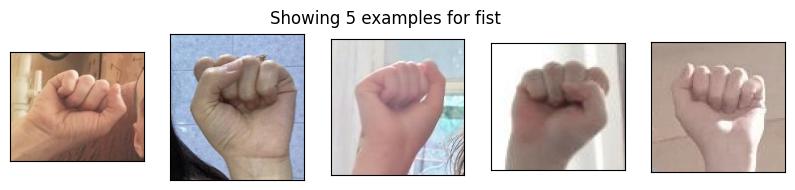

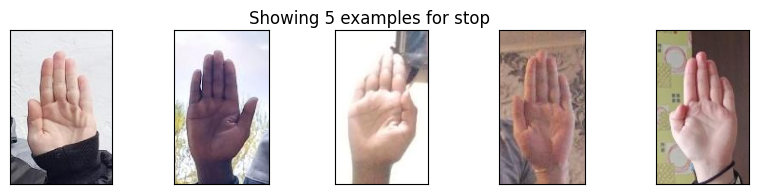

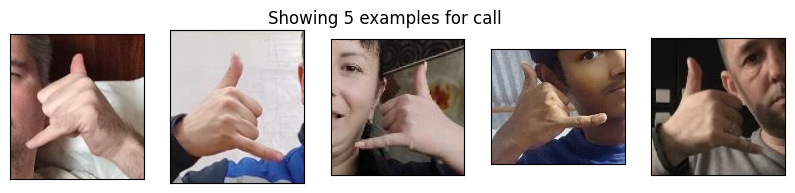

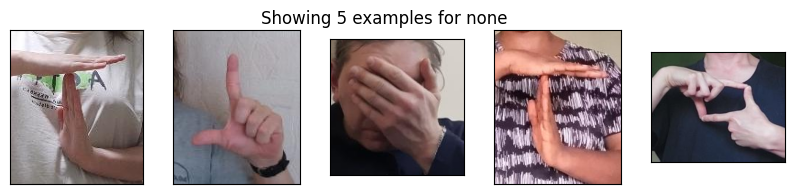

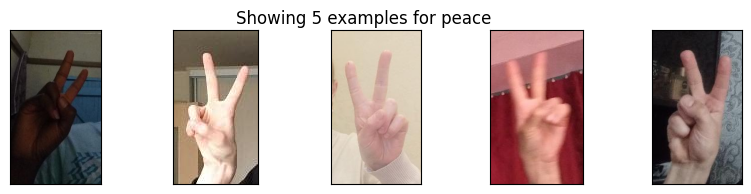

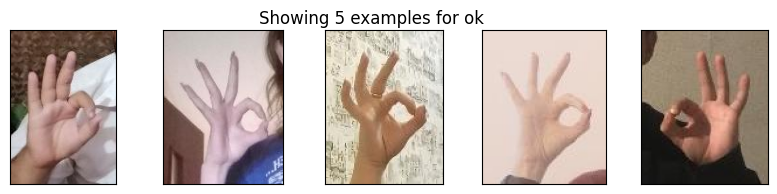

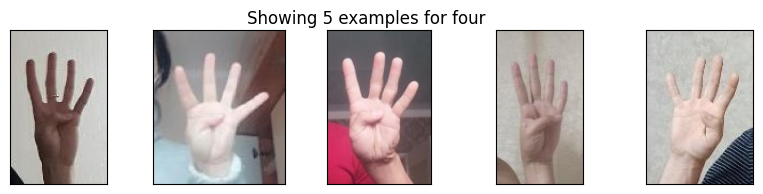

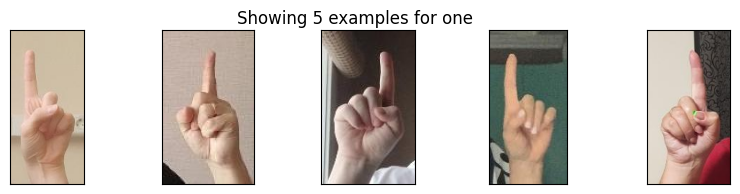

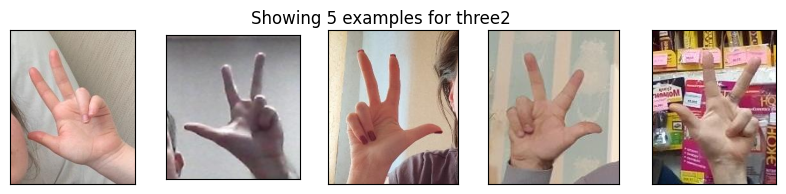

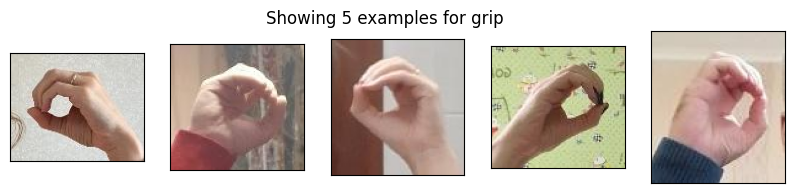

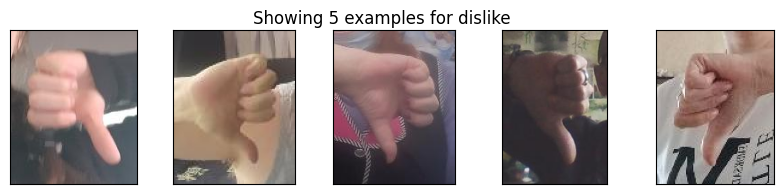

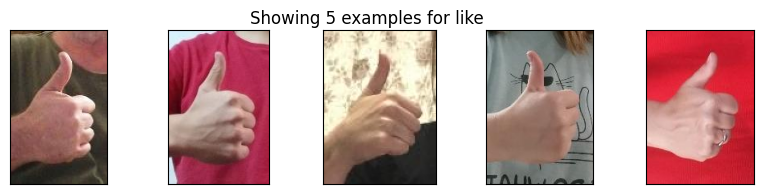

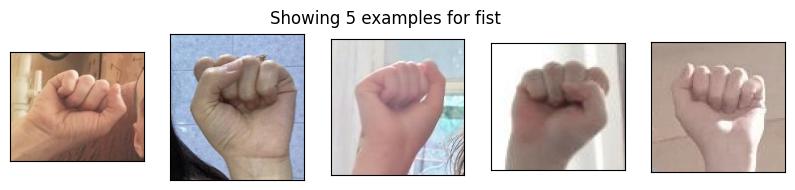

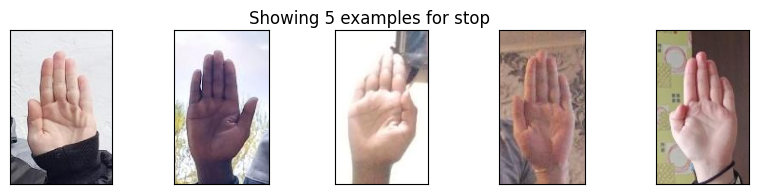

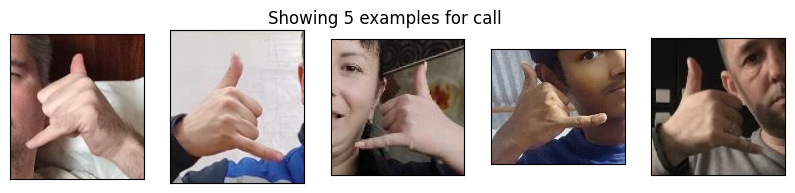

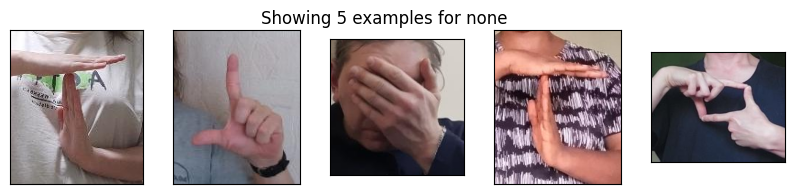

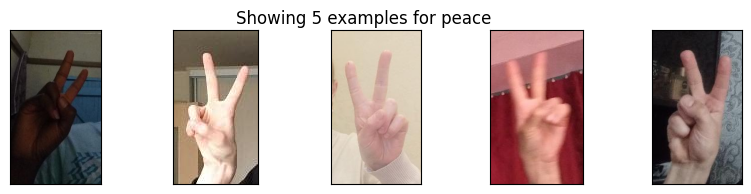

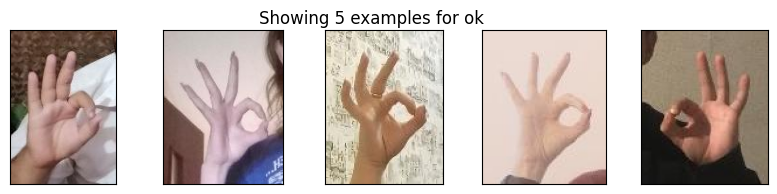

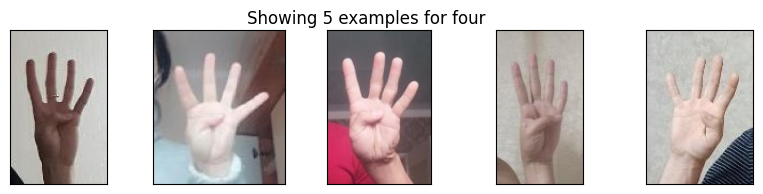

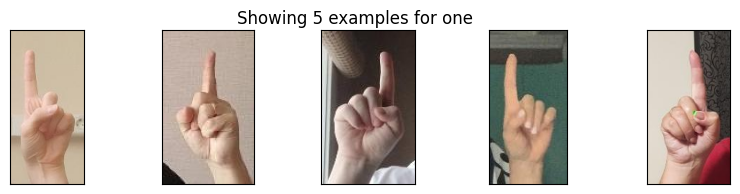

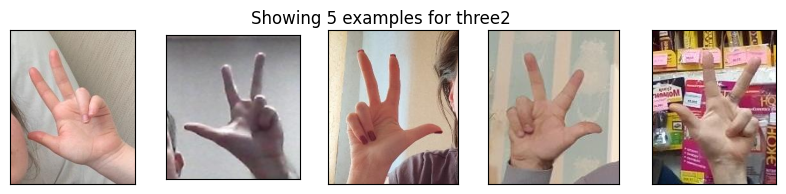

In [6]:
NUM_EXAMPLES = 5

for label in labels:
  label_dir = os.path.join(DATASET_PATHS["train"], label)
  example_filenames = os.listdir(label_dir)[:NUM_EXAMPLES]
  fig, axs = plt.subplots(1, NUM_EXAMPLES, figsize=(10,2))
  for i in range(NUM_EXAMPLES):
    axs[i].imshow(plt.imread(os.path.join(label_dir, example_filenames[i])))
    axs[i].get_xaxis().set_visible(False)
    axs[i].get_yaxis().set_visible(False)
  fig.suptitle(f'Showing {NUM_EXAMPLES} examples for {label}')

plt.show()

In [7]:
train_data = gesture_recognizer.Dataset.from_folder(
    dirname=DATASET_PATHS["train"],
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)
validation_data = gesture_recognizer.Dataset.from_folder(
    dirname=DATASET_PATHS["val"],
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)
test_data = gesture_recognizer.Dataset.from_folder(
    dirname=DATASET_PATHS["test"],
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)

Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/call/607.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/call/98.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/dislike/70.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/call/80.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/call/769.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/ok/92.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/dislike/824.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/fist/564.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/datase

I0000 00:00:1783549552.675749   33769 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1783549552.691299   34202 gl_context.cc:369] GL version: 3.1 (OpenGL ES 3.1 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: D3D12 (NVIDIA GeForce RTX 5070 Ti)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1783549552.730765   34205 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783549552.752180   34211 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783549552.775652   34212 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/none/211.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/fist/247.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/peace/834.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/fist/600.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/one/148.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/ok/251.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/like/524.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/fist/441.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/grip/4.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/train/peace/706.jpg
INFO:tensorflow:Loading image /home/segev/mediapipe-t

2026-07-09 01:29:24.277163: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-09 01:29:24.278262: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Load valid hands with size: 10780, num_label: 12, labels: none,call,dislike,fist,four,grip,like,ok,one,peace,stop,three2.


...

INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/test/stop/28.jpg


INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/test/call/13.jpg


INFO:tensorflow:Loading image /home/segev/mediapipe-training/dataset/images/test/call/13.jpg


Using existing files at /tmp/model_maker/gesture_recognizer/gesture_embedder
INFO:tensorflow:Load valid hands with size: 642, num_label: 12, labels: none,call,dislike,fist,four,grip,like,ok,one,peace,stop,three2.


INFO:tensorflow:Load valid hands with size: 642, num_label: 12, labels: none,call,dislike,fist,four,grip,like,ok,one,peace,stop,three2.


In [ ]:
hparams = gesture_recognizer.HParams(export_dir="exported_model", epochs=50)
options = gesture_recognizer.GestureRecognizerOptions(hparams=hparams)
model = gesture_recognizer.GestureRecognizer.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hand_embedding (InputLayer  [(None, 128)]             0         
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 custom_gesture_recognizer_  (None, 12)                1548      
 out (Dense)                                                     
                                                             

INFO:tensorflow:Training the models...


Epoch 1/10
5390/5390 [==============================] - 6s 1ms/step - loss: 0.8417 - categorical_accuracy: 0.6298 - val_loss: 0.7136 - val_categorical_accuracy: 0.6193 - lr: 0.0010
Epoch 2/10
5390/5390 [==============================] - 6s 1ms/step - loss: 0.6247 - categorical_accuracy: 0.7249 - val_loss: 0.6945 - val_categorical_accuracy: 0.6940 - lr: 9.9000e-04
Epoch 3/10
5390/5390 [==============================] - 7s 1ms/step - loss: 0.5933 - categorical_accuracy: 0.7413 - val_loss: 0.7082 - val_categorical_accuracy: 0.7060 - lr: 9.8010e-04
Epoch 4/10
5390/5390 [==============================] - 7s 1ms/step - loss: 0.5739 - categorical_accuracy: 0.7476 - val_loss: 0.7046 - val_categorical_accuracy: 0.7012 - lr: 9.7030e-04
Epoch 5/10
5390/5390 [==============================] - 6s 1ms/step - loss: 0.5673 - categorical_accuracy: 0.7504 - val_loss: 0.7381 - val_categorical_accuracy: 0.7036 - lr: 9.6060e-04
Epoch 6/10
5390/5390 [==============================] - 5s 1ms/step - loss: 0.5

In [9]:
loss, acc = model.evaluate(test_data, batch_size=1)
print(f"Test loss:{loss}, Test accuracy:{acc}")

642/642 [==============================] - 1s 705us/step - loss: 0.5745 - categorical_accuracy: 0.7617
Test loss:0.5745317339897156, Test accuracy:0.7616822719573975


In [10]:
model.export_model()
!ls exported_model

Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
INFO:tensorflow:Assets written to: /tmp/tmpy2m9hbsj/saved_model/assets


INFO:tensorflow:Assets written to: /tmp/tmpy2m9hbsj/saved_model/assets
2026-07-09 01:31:31.248052: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-09 01:31:31.248107: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-09 01:31:31.248670: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpy2m9hbsj/saved_model
2026-07-09 01:31:31.249263: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-09 01:31:31.249271: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpy2m9hbsj/saved_model
2026-07-09 01:31:31.251098: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-07-09 01:31:31.251468: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-09 01:31:31.266785: I tensorflow/cc/saved_model/

best_model_weights.data-00000-of-00001	epoch_models		 metadata.json
best_model_weights.index		gesture_recognizer.task
checkpoint				logs
